In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
account_data = {
    "account_age_days": [
        800, 650, 500, 30, 15,
        900, 20, 700, 10, 1000,
        25, 550, 12, 850, 40,
        600, 18, 450, 22, 750
    ],

    "posts_per_day": [
        3, 4, 5, 80, 120,
        2, 100, 4, 150, 3,
        90, 5, 130, 2, 75,
        4, 110, 6, 95, 3
    ],

    "followers": [
        1200, 900, 700, 20, 10,
        1500, 15, 800, 5, 2000,
        25, 650, 8, 1300, 30,
        1000, 12, 600, 20, 1100
    ],

    "following": [
        500, 450, 400, 900, 1200,
        550, 1000, 500, 1500, 600,
        1100, 450, 1300, 500, 800,
        550, 1400, 400, 1200, 500
    ],

    "profile_complete": [
        1, 1, 1, 0, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1
    ],

    "fake_account": [
        0, 0, 0, 1, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

accounts_df = pd.DataFrame(account_data)

accounts_df.to_csv(
    "account_data.csv",
    index=False
)

print("Account dataset created!")
print(accounts_df.head())

Account dataset created!
   account_age_days  posts_per_day  followers  following  profile_complete  \
0               800              3       1200        500                 1   
1               650              4        900        450                 1   
2               500              5        700        400                 1   
3                30             80         20        900                 0   
4                15            120         10       1200                 0   

   fake_account  
0             0  
1             0  
2             0  
3             1  
4             1  


In [3]:
X = accounts_df.drop(
    "fake_account",
    axis=1
)

y = accounts_df["fake_account"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

account_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

account_model.fit(
    X_train,
    y_train
)

print("Account-risk model trained successfully!")

Account-risk model trained successfully!


In [4]:
prediction = account_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    prediction
)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        prediction
    )
)

Model Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



In [5]:
risk_probability = account_model.predict_proba(
    accounts_df.drop("fake_account", axis=1)
)[:, 1]

accounts_df["account_risk_score"] = (
    risk_probability * 100
).round(2)

accounts_df["account_risk_level"] = accounts_df[
    "account_risk_score"
].apply(
    lambda x:
        "HIGH" if x >= 70
        else "MEDIUM" if x >= 40
        else "LOW"
)

print(
    accounts_df[
        [
            "account_age_days",
            "posts_per_day",
            "account_risk_score",
            "account_risk_level"
        ]
    ]
)

    account_age_days  posts_per_day  account_risk_score account_risk_level
0                800              3                 0.0                LOW
1                650              4                 0.0                LOW
2                500              5                 0.0                LOW
3                 30             80               100.0               HIGH
4                 15            120               100.0               HIGH
5                900              2                 0.0                LOW
6                 20            100               100.0               HIGH
7                700              4                 0.0                LOW
8                 10            150               100.0               HIGH
9               1000              3                 0.0                LOW
10                25             90               100.0               HIGH
11               550              5                 0.0                LOW
12                12     

In [6]:
security_data = {
    "account_id": range(1, 21),

    "prompt_injection": [
        0, 0, 0, 1, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ],

    "spam_indicator": [
        0, 0, 1, 1, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ],

    "suspicious_url": [
        0, 0, 0, 1, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ],

    "high_posting_activity": [
        0, 0, 0, 1, 1,
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

security_df = pd.DataFrame(
    security_data
)

print(security_df)

    account_id  prompt_injection  spam_indicator  suspicious_url  \
0            1                 0               0               0   
1            2                 0               0               0   
2            3                 0               1               0   
3            4                 1               1               1   
4            5                 1               1               1   
5            6                 0               0               0   
6            7                 1               1               1   
7            8                 0               0               0   
8            9                 1               1               1   
9           10                 0               0               0   
10          11                 1               1               1   
11          12                 0               0               0   
12          13                 1               1               1   
13          14                 0               0

In [7]:
combined_df = accounts_df.copy()

combined_df["account_id"] = range(1, 21)

combined_df = combined_df.merge(
    security_df,
    on="account_id"
)

print(
    combined_df[
        [
            "account_id",
            "account_risk_score",
            "prompt_injection",
            "spam_indicator",
            "suspicious_url",
            "high_posting_activity"
        ]
    ]
)

    account_id  account_risk_score  prompt_injection  spam_indicator  \
0            1                 0.0                 0               0   
1            2                 0.0                 0               0   
2            3                 0.0                 0               1   
3            4               100.0                 1               1   
4            5               100.0                 1               1   
5            6                 0.0                 0               0   
6            7               100.0                 1               1   
7            8                 0.0                 0               0   
8            9               100.0                 1               1   
9           10                 0.0                 0               0   
10          11               100.0                 1               1   
11          12                 0.0                 0               0   
12          13               100.0                 1            

In [10]:
combined_df["security_score"] = (
    combined_df["prompt_injection"] * 30
    + combined_df["spam_indicator"] * 25
    + combined_df["suspicious_url"] * 25
    + combined_df["high_posting_activity"] * 20
)

combined_df["security_score"] = (
    combined_df["security_score"].clip(upper=100)
)

print(
    combined_df[
        [
            "account_id",
            "security_score"
        ]
    ]
)

    account_id  security_score
0            1               0
1            2               0
2            3              25
3            4             100
4            5             100
5            6               0
6            7             100
7            8               0
8            9             100
9           10               0
10          11             100
11          12               0
12          13             100
13          14               0
14          15             100
15          16               0
16          17             100
17          18               0
18          19             100
19          20               0


In [11]:
combined_df["combined_risk_score"] = (
    combined_df["account_risk_score"] * 0.60
    + combined_df["security_score"] * 0.40
)

combined_df["combined_risk_score"] = (
    combined_df["combined_risk_score"]
    .round(2)
)

print(
    combined_df[
        [
            "account_id",
            "account_risk_score",
            "security_score",
            "combined_risk_score"
        ]
    ]
)

    account_id  account_risk_score  security_score  combined_risk_score
0            1                 0.0               0                  0.0
1            2                 0.0               0                  0.0
2            3                 0.0              25                 10.0
3            4               100.0             100                100.0
4            5               100.0             100                100.0
5            6                 0.0               0                  0.0
6            7               100.0             100                100.0
7            8                 0.0               0                  0.0
8            9               100.0             100                100.0
9           10                 0.0               0                  0.0
10          11               100.0             100                100.0
11          12                 0.0               0                  0.0
12          13               100.0             100              

In [12]:
def risk_level(score):

    if score >= 70:
        return "HIGH"

    elif score >= 40:
        return "MEDIUM"

    else:
        return "LOW"


combined_df["final_risk_level"] = (
    combined_df["combined_risk_score"]
    .apply(risk_level)
)

print(
    combined_df[
        [
            "account_id",
            "combined_risk_score",
            "final_risk_level"
        ]
    ]
)

    account_id  combined_risk_score final_risk_level
0            1                  0.0              LOW
1            2                  0.0              LOW
2            3                 10.0              LOW
3            4                100.0             HIGH
4            5                100.0             HIGH
5            6                  0.0              LOW
6            7                100.0             HIGH
7            8                  0.0              LOW
8            9                100.0             HIGH
9           10                  0.0              LOW
10          11                100.0             HIGH
11          12                  0.0              LOW
12          13                100.0             HIGH
13          14                  0.0              LOW
14          15                 98.2             HIGH
15          16                  0.0              LOW
16          17                100.0             HIGH
17          18                  0.0           

In [13]:
def recommended_action(level):

    if level == "HIGH":
        return "FLAG FOR REVIEW"

    elif level == "MEDIUM":
        return "MONITOR"

    else:
        return "ALLOW"


combined_df["recommended_action"] = (
    combined_df["final_risk_level"]
    .apply(recommended_action)
)

print(
    combined_df[
        [
            "account_id",
            "combined_risk_score",
            "final_risk_level",
            "recommended_action"
        ]
    ]
)

    account_id  combined_risk_score final_risk_level recommended_action
0            1                  0.0              LOW              ALLOW
1            2                  0.0              LOW              ALLOW
2            3                 10.0              LOW              ALLOW
3            4                100.0             HIGH    FLAG FOR REVIEW
4            5                100.0             HIGH    FLAG FOR REVIEW
5            6                  0.0              LOW              ALLOW
6            7                100.0             HIGH    FLAG FOR REVIEW
7            8                  0.0              LOW              ALLOW
8            9                100.0             HIGH    FLAG FOR REVIEW
9           10                  0.0              LOW              ALLOW
10          11                100.0             HIGH    FLAG FOR REVIEW
11          12                  0.0              LOW              ALLOW
12          13                100.0             HIGH    FLAG FOR

In [14]:
final_columns = [
    "account_id",
    "account_age_days",
    "posts_per_day",
    "followers",
    "following",
    "profile_complete",
    "account_risk_score",
    "account_risk_level",
    "prompt_injection",
    "spam_indicator",
    "suspicious_url",
    "high_posting_activity",
    "security_score",
    "combined_risk_score",
    "final_risk_level",
    "recommended_action"
]

final_df = combined_df[
    final_columns
]

print(final_df)

    account_id  account_age_days  posts_per_day  followers  following  \
0            1               800              3       1200        500   
1            2               650              4        900        450   
2            3               500              5        700        400   
3            4                30             80         20        900   
4            5                15            120         10       1200   
5            6               900              2       1500        550   
6            7                20            100         15       1000   
7            8               700              4        800        500   
8            9                10            150          5       1500   
9           10              1000              3       2000        600   
10          11                25             90         25       1100   
11          12               550              5        650        450   
12          13                12            130    

In [15]:
final_df.to_csv(
    "combined_account_security_results.csv",
    index=False
)

print(
    "CSV created successfully!"
)

print(
    "File: combined_account_security_results.csv"
)

CSV created successfully!
File: combined_account_security_results.csv


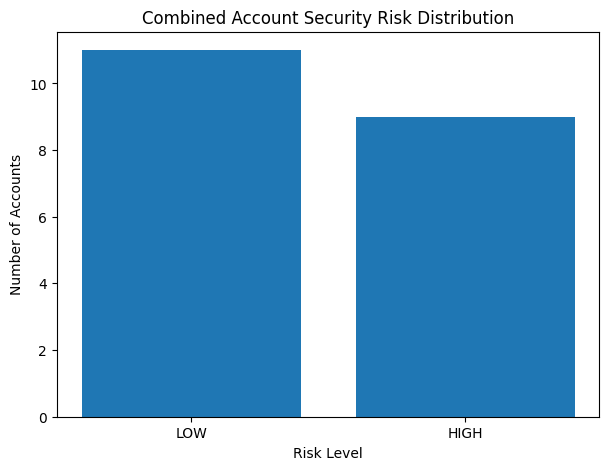

In [16]:
risk_counts = final_df[
    "final_risk_level"
].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    risk_counts.index,
    risk_counts.values
)

plt.title(
    "Combined Account Security Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Accounts")

plt.show()

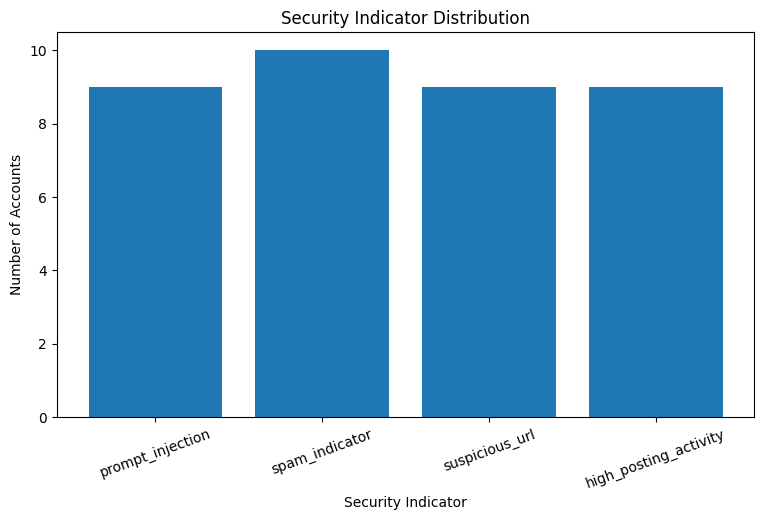

In [17]:
indicators = [
    "prompt_injection",
    "spam_indicator",
    "suspicious_url",
    "high_posting_activity"
]

indicator_counts = [
    final_df[column].sum()
    for column in indicators
]

plt.figure(figsize=(9, 5))

plt.bar(
    indicators,
    indicator_counts
)

plt.title(
    "Security Indicator Distribution"
)

plt.xlabel("Security Indicator")
plt.ylabel("Number of Accounts")

plt.xticks(rotation=20)

plt.show()

In [18]:
from google.colab import files

files.download(
    "combined_account_security_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>